# NumCompute-Stream Demo

This notebook demonstrates the full streaming machine learning workflow for Assignment 2.2.

The demo uses the custom NumCompute-Stream package to:

1. Load a CSV dataset using the custom I/O module.
2. Split the dataset into chunks to simulate streaming data.
3. Build reusable pipelines with preprocessing and models.
4. Train a single decision tree pipeline incrementally using `partial_fit()`.
5. Train an ensemble tree pipeline incrementally using `partial_fit()`.
6. Log cumulative metrics with `StreamTrainer`.
7. Visualise model performance over time using `visualise.py`.


## 1. Imports

Only NumPy and matplotlib are used, along with the custom NumCompute-Stream modules.


In [1]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

# Make sure the project root is importable when running from the demo folder or project root.
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "demo" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from numcompute_stream.io import load_csv
from numcompute_stream.benchmarking import make_stream_chunks
from numcompute_stream.pipeline import Pipeline
from numcompute_stream.preprocessing import SimpleImputer, StandardScaler
from numcompute_stream.tree import DecisionTreeClassifier
from numcompute_stream.ensemble import EnsembleClassifier
from numcompute_stream.stream import StreamTrainer
from numcompute_stream.visualise import (
    plot_metric_over_time,
    compare_models,
    plot_predictions_vs_ground_truth,
)


## 2. Load the dataset

The diabetes dataset is loaded using the custom `load_csv()` function from `io.py`. The final column, `Outcome`, is used as the classification target.


In [2]:
data_path = PROJECT_ROOT / "demo" / "data" / "diabetes.csv"

data, columns = load_csv(str(data_path), skip_header=True)

print("Columns:", columns)
print("Data shape:", data.shape)

X = data[:, :-1]
y = data[:, -1].astype(int)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Class labels:", np.unique(y))


Columns: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']
Data shape: (768, 9)
X shape: (768, 8)
y shape: (768,)
Class labels: [0 1]


## 3. Create streaming chunks

The dataset is shuffled once and split into chunks. Each chunk simulates a new batch of incoming data.


In [3]:
rng = np.random.default_rng(42)
indices = rng.permutation(X.shape[0])

X_stream = X[indices]
y_stream = y[indices]

chunk_size = 64
chunks = list(make_stream_chunks(X_stream, y_stream, chunk_size=chunk_size))

print("Number of chunks:", len(chunks))
print("First chunk X shape:", chunks[0][0].shape)
print("First chunk y shape:", chunks[0][1].shape)


Number of chunks: 12
First chunk X shape: (64, 8)
First chunk y shape: (64,)


## 4. Build streaming pipelines

Both models are wrapped inside the custom `Pipeline` class. This demonstrates chained streaming updates where preprocessing and the final model are updated chunk by chunk using `partial_fit()`.

Each pipeline contains:

- `SimpleImputer` for missing-value handling
- `StandardScaler` for running feature scaling
- a tree-based classifier as the final model


In [4]:
tree_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler()),
    ("model", DecisionTreeClassifier(
        max_depth=4,
        min_samples_split=5,
        criterion="gini",
        random_state=42,
    )),
])

ensemble_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler()),
    ("model", EnsembleClassifier(
        n_estimators=7,
        max_depth=4,
        min_samples_split=5,
        criterion="gini",
        max_features=4,
        bootstrap=True,
        random_state=42,
    )),
])

print(tree_pipeline)
print(ensemble_pipeline)


Pipeline(steps=[('imputer', SimpleImputer), ('scaler', StandardScaler), ('model', DecisionTreeClassifier)])
Pipeline(steps=[('imputer', SimpleImputer), ('scaler', StandardScaler), ('model', EnsembleClassifier)])


## 5. Train the decision tree pipeline incrementally

`StreamTrainer` calls `partial_fit()` on each chunk and logs per-chunk accuracy, cumulative accuracy, fit time, prediction time, and approximate memory usage.


In [5]:
tree_trainer = StreamTrainer(tree_pipeline)
tree_trainer.fit_stream(chunks)

tree_history = tree_trainer.get_history()
tree_scores = tree_trainer.get_history("score")
tree_cumulative = tree_trainer.get_history("cumulative_accuracy")

print("Tree final chunk accuracy:", tree_scores[-1])
print("Tree cumulative accuracy:", tree_cumulative[-1])
print("Logged chunks:", len(tree_history))


Tree final chunk accuracy: 0.734375
Tree cumulative accuracy: 0.8424479166666666
Logged chunks: 12


## 6. Train the ensemble pipeline incrementally

The ensemble pipeline uses the same streaming interface as the single-tree pipeline, showing API consistency between base and ensemble models.


In [6]:
ensemble_trainer = StreamTrainer(ensemble_pipeline)
ensemble_trainer.fit_stream(chunks)

ensemble_history = ensemble_trainer.get_history()
ensemble_scores = ensemble_trainer.get_history("score")
ensemble_cumulative = ensemble_trainer.get_history("cumulative_accuracy")

print("Ensemble final chunk accuracy:", ensemble_scores[-1])
print("Ensemble cumulative accuracy:", ensemble_cumulative[-1])
print("Logged chunks:", len(ensemble_history))


Ensemble final chunk accuracy: 0.765625
Ensemble cumulative accuracy: 0.8515625
Logged chunks: 12


## 7. Visualise cumulative accuracy

The plotting functions come from the custom `visualise.py` module.


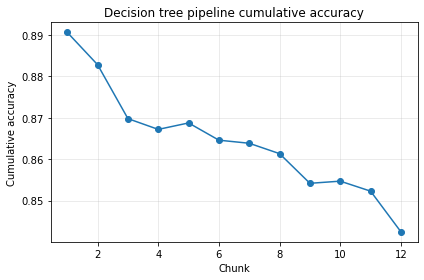

In [7]:
fig, ax = plot_metric_over_time(
    tree_cumulative,
    title="Decision tree pipeline cumulative accuracy",
    ylabel="Cumulative accuracy",
)
plt.show()


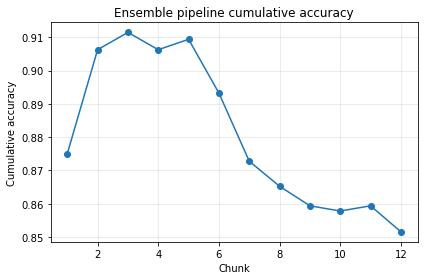

In [8]:
fig, ax = plot_metric_over_time(
    ensemble_cumulative,
    title="Ensemble pipeline cumulative accuracy",
    ylabel="Cumulative accuracy",
)
plt.show()


## 8. Compare decision tree and ensemble pipelines


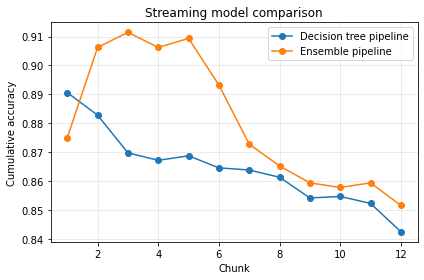

In [9]:
fig, ax = compare_models(
    tree_cumulative,
    ensemble_cumulative,
    labels=("Decision tree pipeline", "Ensemble pipeline"),
    title="Streaming model comparison",
    ylabel="Cumulative accuracy",
)
plt.show()


## 9. Predictions vs ground truth on the latest chunk

This plot compares the ensemble pipeline predictions with the actual labels for the latest stream chunk.


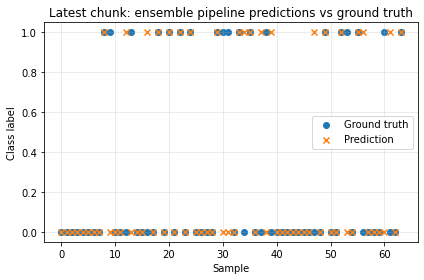

In [10]:
X_last, y_last = chunks[-1]
y_pred_last = ensemble_pipeline.predict(X_last)

fig, ax = plot_predictions_vs_ground_truth(
    y_last,
    y_pred_last,
    title="Latest chunk: ensemble pipeline predictions vs ground truth",
)
plt.show()


## 10. Inspect stream logs

The stream logs provide evidence of chunk-wise processing and metric tracking.


In [11]:
print("Last 3 decision tree log entries:")
for row in tree_history[-3:]:
    print(row)

print("\nLast 3 ensemble log entries:")
for row in ensemble_history[-3:]:
    print(row)


Last 3 decision tree log entries:
{'chunk_index': 10, 'n_samples': 64, 'score': 0.859375, 'cumulative_accuracy': 0.8546875, 'fit_time': 0.7815774160000011, 'predict_time': 0.00010008299999952897, 'memory_bytes': 360}
{'chunk_index': 11, 'n_samples': 64, 'score': 0.828125, 'cumulative_accuracy': 0.8522727272727273, 'fit_time': 0.8569868750000005, 'predict_time': 0.00012270799999924975, 'memory_bytes': 360}
{'chunk_index': 12, 'n_samples': 64, 'score': 0.734375, 'cumulative_accuracy': 0.8424479166666666, 'fit_time': 0.9495479580000001, 'predict_time': 9.975000000039813e-05, 'memory_bytes': 360}

Last 3 ensemble log entries:
{'chunk_index': 10, 'n_samples': 64, 'score': 0.84375, 'cumulative_accuracy': 0.8578125, 'fit_time': 1.8308597920000018, 'predict_time': 0.001362416999999283, 'memory_bytes': 360}
{'chunk_index': 11, 'n_samples': 64, 'score': 0.875, 'cumulative_accuracy': 0.859375, 'fit_time': 2.0508957909999985, 'predict_time': 0.0014177920000015831, 'memory_bytes': 360}
{'chunk_inde

## 11. Summary

This demo satisfies the streaming workflow requirements:

- The dataset is loaded from CSV using the custom I/O module.
- Data is split into chunks to simulate streaming input.
- Both models are placed inside reusable pipelines.
- Each pipeline is trained incrementally using `partial_fit()`.
- `StreamTrainer` logs chunk-level metrics, cumulative accuracy, timing, and memory estimates.
- `visualise.py` is used to plot metric trends, model comparison, and predictions against ground truth.
